# SW Point-analysis plots 2023

In [1]:
import xarray as xr
import numpy as np

import matplotlib.pyplot as plt
import matplotlib.dates as mdates

import pandas as pd
import os

In [2]:
# MODELED DATA

save_dir = 'modeled-station-2023'
save_dirs3 = 's3-new'
save_dirm1 = 'm1-dir-dif'

s3_dsw3 = xr.open_dataset(os.path.join(save_dirs3, 's3_dsw3_23.nc'))
s3_dsw1 = xr.open_dataset(os.path.join(save_dirs3, 's3_dsw1_23.nc'))
s3_dsw30 = xr.open_dataset(os.path.join(save_dirs3, 's3_dsw30_23.nc'))
s3_k = xr.open_dataset(os.path.join(save_dirs3, 's3_k_23.nc'))
s3_ghi = xr.open_dataset(os.path.join(save_dirs3, 's3_ghi_23.nc'))

m1_dsw3 = xr.open_dataset(os.path.join(save_dir, 'm1_dsw3.nc'))
m1_dsw1 = xr.open_dataset(os.path.join(save_dir, 'm1_dsw1.nc'))
m1_dsw30 = xr.open_dataset(os.path.join(save_dir, 'm1_dsw30.nc'))
m1_k = xr.open_dataset(os.path.join(save_dir, 'm1_k.nc'))
m1_ghi = xr.open_dataset(os.path.join(save_dir, 'm1_ghi.nc'))
m1_dir22 = xr.open_dataset(os.path.join(save_dirm1, 'm1_dir_23.nc'))
m1_dif22 = xr.open_dataset(os.path.join(save_dirm1, 'm1_dif_23.nc'))

irwin_dsw3 = xr.open_dataset(os.path.join(save_dir, 'irwin_dsw3.nc'))
irwin_dsw30 = xr.open_dataset(os.path.join(save_dir, 'irwin_dsw30.nc'))
irwin_dsw1 = xr.open_dataset(os.path.join(save_dir, 'irwin_dsw1.nc'))
irwin_k = xr.open_dataset(os.path.join(save_dir, 'irwin_k.nc'))
irwin_ghi = xr.open_dataset(os.path.join(save_dir, 'irwin_ghi.nc'))

sos_dsw3 = xr.open_dataset(os.path.join(save_dir, 'sos_dsw3.nc'))
sos_dsw1 = xr.open_dataset(os.path.join(save_dir, 'sos_dsw1.nc'))
sos_dsw30 = xr.open_dataset(os.path.join(save_dir, 'sos_dsw30.nc'))
sos_k = xr.open_dataset(os.path.join(save_dir, 'sos_k.nc'))
sos_ghi = xr.open_dataset(os.path.join(save_dir, 'sos_ghi.nc'))

In [3]:
# STATION DATA

save_dir = 'station-data'

# SAIL M1 QCRAD LONG
subset_sw_hourly = xr.open_dataset(os.path.join(save_dir, 'm1qc_sw.nc'))
subset_dif_hourly = xr.open_dataset(os.path.join(save_dir, 'm1qc_diff.nc'))
subset_dir_hourly = xr.open_dataset(os.path.join(save_dir, 'm1qc_dir.nc'))
subset_best_hourly = xr.open_dataset(os.path.join(save_dir, 'm1qc_best_sw.nc'))
subset_zenith_hourly = xr.open_dataset(os.path.join(save_dir, 'm1qc_zen.nc'))
sub_dirh_hourly = xr.open_dataset(os.path.join(save_dir, 'm1qc_dirh.nc'))
sub_difh_hourly = xr.open_dataset(os.path.join(save_dir, 'm1qc_difh_xx.nc'))
sub_dirh_hourly = sub_dirh_hourly['__xarray_dataarray_variable__'].rename('short_direct_normal').to_dataset()

# SAIL M1 & S3
m1_sw_hourly_sail = xr.open_dataset(os.path.join(save_dir, 'm1_sw.nc'))
s3_sw_hourly_sail = xr.open_dataset(os.path.join(save_dir, 's3_sw.nc'))

# SOS
sos_path = '/uufs/chpc.utah.edu/common/home/u1037042/olson/snow-data/station-data/sos-isfs/hourlyAvg_radiation_uw.nc'
sos_sw_hourly_sail = xr.open_dataset(sos_path)

In [4]:
## Read in IRWin Station Data
from pathlib import Path, PurePath
# SHARED_STORE = PurePath('/uufs/chpc.utah.edu/common/home/skiles-group1')
CSV_PATH = PurePath('/uufs/chpc.utah.edu/common/home/u1037042/olson/snow-data/station-data/irwin/Irwin_rad_15min_2019_2023.csv')

irwin_pyra = pd.concat([
    # pd.read_csv(DATA_DIR / 'Snotel/wy2021/Irwin/2021-Irwin.csv', **PD_OPTS),
    pd.read_csv(CSV_PATH)
])

# Rename and select relevant columns
irwin_pyra = irwin_pyra.rename(columns={
    'TIMESTAMP': 'date',
    'Incoming_Solar_Wm2_1_Avg': 'VIS_IN'
})[['date', 'VIS_IN']]

# Convert 'date' column to datetime
irwin_pyra['date'] = pd.to_datetime(irwin_pyra['date'], format='%m/%d/%Y %H:%M')

irwin_pyra = irwin_pyra.set_index('date')

# Fill missing VIS_IN values with 0 and convert to float64
irwin_pyra['VIS_IN'] = irwin_pyra['VIS_IN'].fillna(0).astype(np.float64)

# irwin_pyra

### Select year

In [5]:
start_wy2022 = '2022-12-01 00:00'
end_wy2022   = '2023-05-01 23:00'
win = 24  # 24-hour rolling window

# SOS station
sos_obs_hourly = sos_sw_hourly_sail['Rsw_in_uw'].sel(time=slice(start_wy2022, end_wy2022)).clip(min=0)
sos_obs_smoothed = sos_obs_hourly.rolling(time=win, center=True).mean()
# S3 Modeled
sos_model_smoothed = sos_dsw3.sel(time=slice(start_wy2022, end_wy2022)).rolling(time=win, center=True).mean()
sos_k_smoothed = sos_k.sel(time=slice(start_wy2022, end_wy2022)).rolling(time=1, center=True).mean()

# SAIL S3 Station
s3_obs_hourly = s3_sw_hourly_sail['down_short_hemisp'].sel(time=slice(start_wy2022, end_wy2022)).clip(min=0)
s3_obs_smoothed = s3_obs_hourly.rolling(time=win, center=True).mean()
# S3 Modeled
s3_model_smoothed = s3_dsw3.sel(time=slice(start_wy2022, end_wy2022)).rolling(time=win, center=True).mean()
s3_k_smoothed = s3_k.sel(time=slice(start_wy2022, end_wy2022)).rolling(time=1, center=True).mean()

# SAIL M1 Station
m1_obs_hourly0 = m1_sw_hourly_sail['down_short_hemisp'].sel(time=slice(start_wy2022, end_wy2022))
m1_obs_smoothed = m1_obs_hourly0.rolling(time=win, center=True).mean()
# M1 QCRAD
m1_obs_hourly = subset_best_hourly['BestEstimate_down_short_hemisp'].sel(time=slice(start_wy2022, end_wy2022))
m1qc_obs_smoothed = m1_obs_hourly.rolling(time=win, center=True).mean()
dir_obs = subset_dir_hourly['short_direct_normal'].sel(time=slice(start_wy2022, end_wy2022)).clip(min=0)
dirh_obs = sub_dirh_hourly['short_direct_normal'].sel(time=slice(start_wy2022, end_wy2022)).clip(min=0)
dif_obs = subset_dif_hourly['down_short_diffuse_hemisp'].sel(time=slice(start_wy2022, end_wy2022)).clip(min=0)
dir_obs_smoothed = dir_obs.rolling(time=win, center=True).mean()
dirh_obs_smoothed = dirh_obs.rolling(time=win, center=True).mean()
dif_obs_smoothed = dif_obs.rolling(time=win, center=True).mean()
# M1 Modeled
m1_model_smoothed = m1_dsw3.sel(time=slice(start_wy2022, end_wy2022)).rolling(time=win, center=True).mean()
m1_k_smoothed = m1_k.sel(time=slice(start_wy2022, end_wy2022)).rolling(time=1, center=True).mean()
dirh_model = m1_dir22['dir'] * np.cos(np.deg2rad(subset_zenith_hourly.clip(min=0, max=90))).clip(min=0, max=1)
dirh_model = dirh_model['zenith'].rename('dsw3h').to_dataset().sel(time=slice(start_wy2022, end_wy2022)).clip(min=0)
dirh_model_smoothed = dirh_model.rolling(time=win, center=True).mean()
dif_model = m1_dif22['dif'].sel(time=slice(start_wy2022, end_wy2022)).clip(min=0)
dif_model = dif_model.rename('dsw3h').to_dataset()


dif_model_smoothed = dif_model.rolling(time=win, center=True).mean()

# ======= Irwin Station (Pandas-based) =======
irwin_pyra_hourly = irwin_pyra.resample('1h').mean()
irwin_pyra_hourly.index = pd.to_datetime(irwin_pyra_hourly.index)
irwin_obs_hourly = irwin_pyra_hourly.loc[start_wy2022:end_wy2022]
irwin_obs_smoothed = irwin_obs_hourly['VIS_IN'].rolling(window=win, center=True).mean()
# irwin_obs = irwin_obs.where(irwin_obs > 0)
# Irwin Modeled
irwin_model_smoothed = irwin_dsw3.sel(time=slice(start_wy2022, end_wy2022)).rolling(time=win, center=True).mean()
irwin_k_smoothed = irwin_k.sel(time=slice(start_wy2022, end_wy2022)).rolling(time=1, center=True).mean()

### Bias calculation

In [6]:

# Define time range
start = np.datetime64('2022-12-01')
end = np.datetime64('2023-05-01')
k_thresh = 0.6

def compute_bias_and_category2(obs_da, model_ds, k_ds, station_name, start, end, k_thresh):
    # Slice and convert to pandas Series
    obs = obs_da.sel(time=slice(start, end)).to_series()
    model = model_ds['dsw3h'].sel(time=slice(start, end)).to_series()
    k = k_ds['k'].sel(time=slice(start, end)).to_series()

    # Filter invalid values (<= 0 or > 1000)
    obs = obs.where((obs > 0) & (obs <= 1100))
    model = model.where((model > 0) & (model <= 1100))
    k = k.where((k >= 0) & (k <= 1))

    # Combine and align all time series
    df = pd.concat([obs, model, k], axis=1, keys=['obs', 'model', 'k']).dropna()

    # Compute bias and category
    df['bias'] = df['model'] - df['obs']
    df['category'] = np.where(df['k'] < k_thresh, 'Clear', 'Cloudy')
    df['station'] = station_name

    return df[['station', 'bias', 'category']]


# S3 and M1 from xarray
s3_df = compute_bias_and_category2(s3_obs_hourly, s3_dsw3, s3_k, 'SAIL S3', start, end, k_thresh)
sos_df = compute_bias_and_category2(sos_obs_hourly, sos_dsw3, sos_k, 'SOS', start, end, k_thresh)
m1_df = compute_bias_and_category2(m1_obs_hourly, m1_dsw3, m1_k, 'SAIL M1 QCRAD', start, end, k_thresh)

# Irwin from pandas
irwin_obs_clipped = irwin_obs_hourly['VIS_IN'].loc[start:end].copy()
irwin_obs_clipped[irwin_obs_clipped <= 0] = np.nan  # Set zero or negative to NaN

irwin_df = pd.DataFrame({
    'obs': irwin_obs_clipped,
    'model': irwin_dsw3['dsw3h'].sel(time=slice(start, end)).to_series(),
    'k': irwin_k['k'].sel(time=slice(start, end)).to_series()
}).dropna()

irwin_df = irwin_df.where(irwin_df['model'] > 0).dropna()

irwin_df['bias'] = irwin_df['model'] - irwin_df['obs']
irwin_df['category'] = np.where(irwin_df['k'] < k_thresh, 'Clear', 'Cloudy')
irwin_df['station'] = 'Irwin Study Plot'
irwin_df = irwin_df[['station', 'bias', 'category']]

# Combine all
combined_df = pd.concat([s3_df, m1_df, irwin_df])



In [7]:
# LIMIT to 96% distribution

def limit_2_98(df):
    # Calculate the 2nd and 98th percentiles
    lower_percentile = df['bias'].quantile(0.02)
    upper_percentile = df['bias'].quantile(0.98)
    
    # Filter the DataFrame to keep values within the range
    df_filtered = df[(df['bias'] >= lower_percentile) & (df['bias'] <= upper_percentile)]
    
    return(df_filtered)



m1_df2 = limit_2_98(m1_df)
s3_df2 = limit_2_98(s3_df)
sos_df2 = limit_2_98(sos_df)
irwin_df2 = limit_2_98(irwin_df)

In [8]:
print("SW Bias (Modeled - Station) - 2 & 98")
print("\nSAIL M1 QCRAD:")
print(m1_df2.groupby('category')['bias'].agg(['min', 'mean', 'max']))
print("SAIL S3:")
print(s3_df2.groupby('category')['bias'].agg(['min', 'mean', 'max']))
print("\nSOS Study Plot:")
print(sos_df2.groupby('category')['bias'].agg(['min', 'mean', 'max']))
print("\nIrwin Study Plot:")
print(irwin_df2.groupby('category')['bias'].agg(['min', 'mean', 'max']))

SW Bias (Modeled - Station) - 2 & 98

SAIL M1 QCRAD:
                 min       mean         max
category                                   
Clear    -171.403320  37.126450  398.022949
Cloudy   -184.887634  86.486938  408.631500
SAIL S3:
                min        mean         max
category                                   
Clear    -76.245178   95.543884  412.205078
Cloudy   -78.522705  102.393517  443.115906

SOS Study Plot:
                 min        mean         max
category                                    
Clear    -150.745270   86.973907  446.895050
Cloudy   -147.332153  117.676643  446.207428

Irwin Study Plot:
                 min       mean         max
category                                   
Clear    -219.561952  68.894716  487.126603
Cloudy   -220.688134  75.994627  486.218090


In [10]:
print("M1: " + str(m1_df2['bias'].mean()))
print("S3: " + str(s3_df2['bias'].mean()))
print("SOS: " + str(sos_df2['bias'].mean()))
print("Irwin: " + str(irwin_df2['bias'].mean()))

M1: 58.30871
S3: 98.670204
SOS: 100.98727
Irwin: 72.72023851466157


In [11]:
print("M1: " + str(m1_df2['bias'].std()))
print("S3: " + str(s3_df2['bias'].std()))
print("SOS: " + str(sos_df2['bias'].std()))
print("Irwin: " + str(irwin_df2['bias'].mean()))

M1: 128.18971
S3: 96.83794
SOS: 125.10674
Irwin: 132.9030136374188


## Figure 1

/scratch/local/u1037042/6836649/ipykernel_3237711/3882593167.py:31: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.violinplot(data=m1_df2, x='category', y='bias',
/scratch/local/u1037042/6836649/ipykernel_3237711/3882593167.py:63: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.violinplot(data=s3_df2, x='category', y='bias',
/scratch/local/u1037042/6836649/ipykernel_3237711/3882593167.py:92: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.violinplot(data=sos_df2, x='category', y='bias',
/scratch/local/u1037042/6836649/ipykernel_3237711/3882593167.py:121: FutureWarning: 

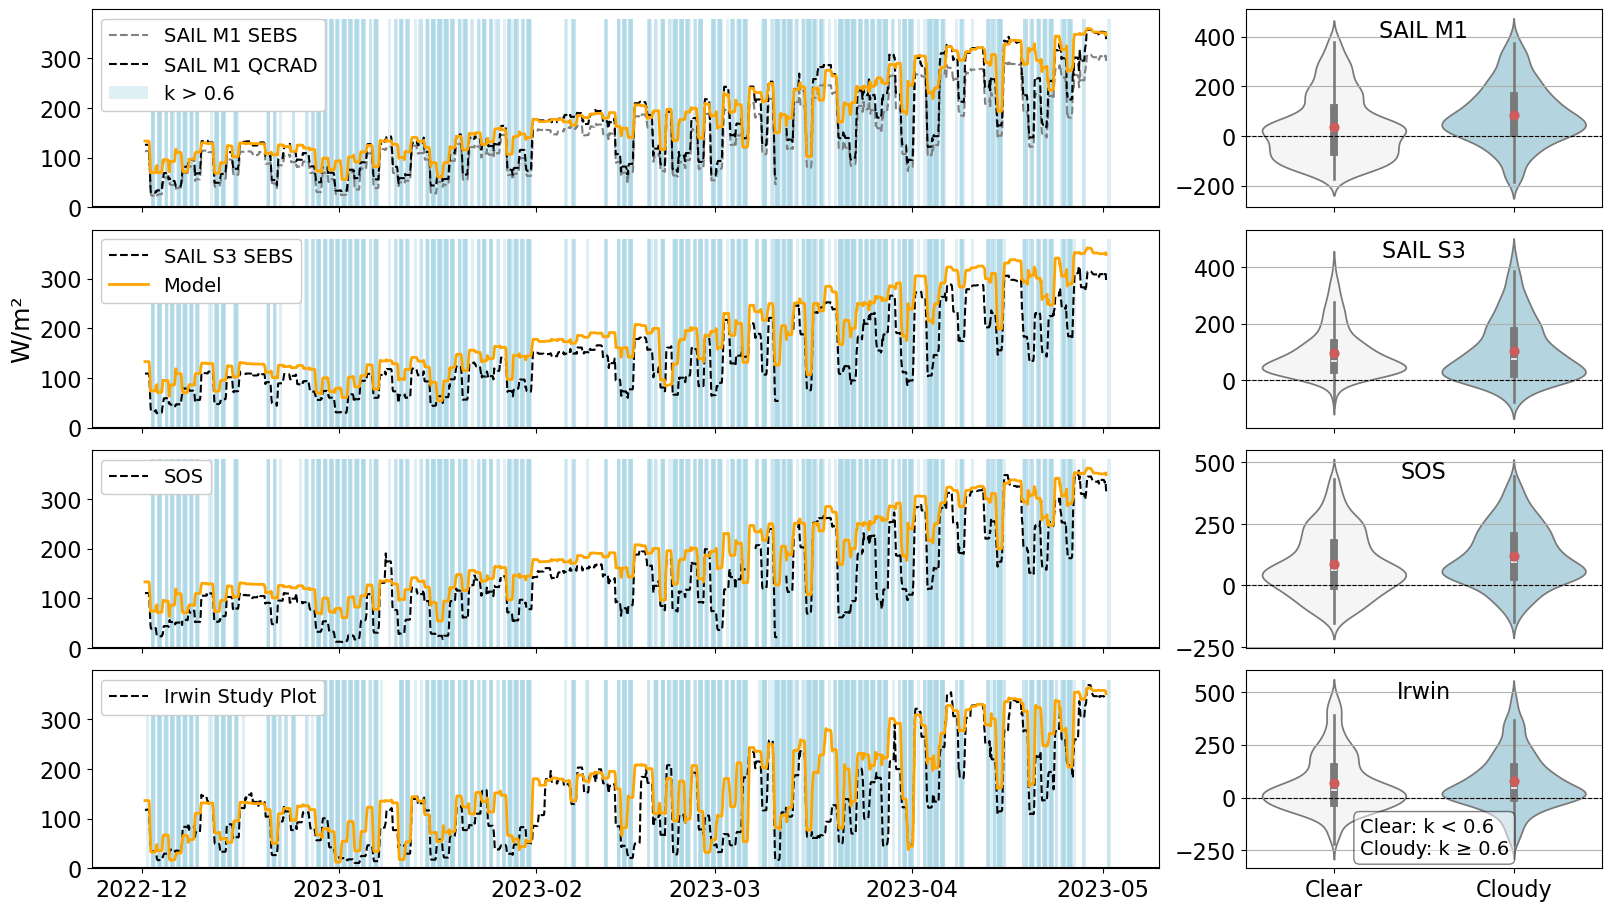

In [10]:
import seaborn as sns
import matplotlib.pyplot as plt
import pandas as pd
import numpy as np

fig, axes = plt.subplots(
    nrows=4, ncols=2, figsize=(16, 9),
    sharex='col', #sharey='row',
    gridspec_kw={'width_ratios': [3, 1]},
    constrained_layout=True
)

# Font sizes
tick_size = 16
legend_size = 14
label_size = 18
lwd = 2
# k_thresh = 0.8

# ==== Row 1: M1 ====
axes[0, 0].bar(m1_k_smoothed['time'], (m1_k_smoothed['k'] > k_thresh) * 380, #m1_model_smoothed['dsw3h'].max(),
               color='lightblue', width=0.5, alpha=0.4, label='k > 0.6')
axes[0, 0].plot(m1_obs_smoothed['time'], m1_obs_smoothed, linestyle='--', color='grey', label='SAIL M1 SEBS')
axes[0, 0].plot(m1qc_obs_smoothed['time'], m1qc_obs_smoothed, linestyle='--', color='black', label='SAIL M1 QCRAD')
axes[0, 0].plot(m1_model_smoothed['time'], m1_model_smoothed['dsw3h'], color='orange', linewidth=lwd, label='')
axes[0, 0].axhline(0, color='black')
axes[0, 0].legend(fontsize=legend_size, framealpha=1, loc='upper left')
# axes[0, 0].set_ylabel('W/m²', fontsize=label_size)
axes[0, 0].tick_params(labelsize=tick_size)

sns.violinplot(data=m1_df2, x='category', y='bias',
               palette={'Clear': 'whitesmoke', 'Cloudy': 'lightblue'},
               ax=axes[0, 1])

axes[0, 1].axhline(0, color='black', linestyle='--', linewidth=0.8)
axes[0, 1].set_ylabel("")
axes[0, 1].set_xlabel("")
axes[0, 1].grid(True, axis='y')
# axes[0, 1].legend().remove()
axes[0, 1].tick_params(labelsize=tick_size)
axes[0, 1].text(0.5, 0.95, 'SAIL M1', transform=axes[0,1].transAxes,
             fontsize=16, va='top', ha='center')

m1_means = m1_df2.groupby('category')['bias'].mean()
for i, cat in enumerate(['Clear', 'Cloudy']):
    axes[0, 1].scatter(i, m1_means[cat], color='indianred', zorder=5, s=40)




# ==== Row 0: S3 ====
# -- Time Series --
axes[1, 0].bar(s3_k_smoothed['time'], (s3_k_smoothed['k'] > k_thresh) * 380, # s3_model_smoothed['dsw3h'].max(),
               color='lightblue', width=0.5, alpha=0.4)
axes[1, 0].plot(s3_obs_smoothed['time'], s3_obs_smoothed, color='black', linestyle='--', label='SAIL S3 SEBS')
axes[1, 0].plot(s3_model_smoothed['time'], s3_model_smoothed['dsw3h'], color='orange', linewidth=lwd, label='Model')
axes[1, 0].axhline(0, color='black')
axes[1, 0].legend(fontsize=legend_size, framealpha=1, loc='upper left')
axes[1, 0].set_ylabel('W/m²', fontsize=label_size)
axes[1, 0].tick_params(labelsize=tick_size)

# -- Violin Plot --
sns.violinplot(data=s3_df2, x='category', y='bias',
               palette={'Clear': 'whitesmoke', 'Cloudy': 'lightblue'},
               ax=axes[1, 1])
axes[1, 1].axhline(0, color='black', linestyle='--', linewidth=0.8)
axes[1, 1].set_ylabel("")
axes[1, 1].set_xlabel("")
axes[1, 1].grid(True, axis='y')
# axes[1, 1].legend().remove()
axes[1, 1].tick_params(labelsize=tick_size)
axes[1, 1].text(0.5, 0.95, 'SAIL S3', transform=axes[1,1].transAxes,
             fontsize=16, va='top', ha='center')

# Add mean bias dot
s3_means = s3_df2.groupby('category')['bias'].mean()
for i, cat in enumerate(['Clear', 'Cloudy']):
    axes[1, 1].scatter(i, s3_means[cat], color='indianred', zorder=5, s=40)



# # # # # ADD SOS
axes[2, 0].bar(sos_k_smoothed['time'], (sos_k_smoothed['k'] > k_thresh) * 380, # irwin_model_smoothed['dsw3h'].max(),
               color='lightblue', width=0.5, alpha=0.4)
axes[2, 0].plot(sos_obs_smoothed['time'], sos_obs_smoothed, linestyle='--', color='black', label='SOS')
axes[2, 0].plot(sos_model_smoothed['time'], sos_model_smoothed['dsw3h'], color='orange', linewidth=lwd, label='')
axes[2, 0].axhline(0, color='black')
axes[2, 0].legend(fontsize=legend_size, framealpha=1, loc='upper left')
# axes[2, 0].set_ylabel('W/m²', fontsize=label_size)
axes[2, 0].tick_params(labelsize=tick_size)

sns.violinplot(data=sos_df2, x='category', y='bias',
               palette={'Clear': 'whitesmoke', 'Cloudy': 'lightblue'},
               ax=axes[2, 1])

axes[2, 1].axhline(0, color='black', linestyle='--', linewidth=0.8)
axes[2, 1].set_ylabel("")
axes[2, 1].set_xlabel("")
axes[2, 1].grid(True, axis='y')
# axes[2, 1].legend().remove()
axes[2, 1].tick_params(labelsize=tick_size)
axes[2, 1].text(0.5, 0.95, 'SOS', transform=axes[2,1].transAxes,
             fontsize=16, va='top', ha='center')

sos_means = sos_df2.groupby('category')['bias'].mean()
for i, cat in enumerate(['Clear', 'Cloudy']):
    axes[2, 1].scatter(i, sos_means[cat], color='indianred', zorder=5, s=40)

# # # # # #

# ==== Row 2: Irwin ====
axes[3, 0].bar(irwin_k_smoothed['time'], (irwin_k_smoothed['k'] > k_thresh) * 380, # irwin_model_smoothed['dsw3h'].max(),
               color='lightblue', width=0.5, alpha=0.4)
axes[3, 0].plot(irwin_obs_smoothed.index, irwin_obs_smoothed, linestyle='--', color='black', label='Irwin Study Plot')
axes[3, 0].plot(irwin_model_smoothed['time'], irwin_model_smoothed['dsw3h'], color='orange', linewidth=lwd, label='')
axes[3, 0].axhline(0, color='black')
axes[3, 0].legend(fontsize=legend_size, framealpha=1, loc='upper left')
# axes[2, 0].set_ylabel('W/m²', fontsize=label_size)
axes[3, 0].tick_params(labelsize=tick_size)

sns.violinplot(data=irwin_df2, x='category', y='bias',
               palette={'Clear': 'whitesmoke', 'Cloudy': 'lightblue'},
               ax=axes[3, 1])

axes[3, 1].axhline(0, color='black', linestyle='--', linewidth=0.8)
axes[3, 1].set_ylabel("")
axes[3, 1].set_xlabel("")
axes[3, 1].grid(True, axis='y')
# axes[2, 1].legend().remove()
axes[3, 1].tick_params(labelsize=tick_size)
axes[3, 1].text(0.5, 0.95, 'Irwin', transform=axes[3,1].transAxes,
             fontsize=16, va='top', ha='center')

irwin_means = irwin_df2.groupby('category')['bias'].mean()
for i, cat in enumerate(['Clear', 'Cloudy']):
    axes[3, 1].scatter(i, irwin_means[cat], color='indianred', zorder=5, s=40)

# # #

# Text and box properties
textstr = "Clear: k < 0.6\nCloudy: k ≥ 0.6"
props = dict(boxstyle='round', facecolor='white', alpha=0.5, edgecolor='black')

# Place it in bottom-left
axes[3, 1].text(
    0.32, 0.05, textstr,
    # transform=ax.transAxes,
    transform=axes[3,1].transAxes,
    fontsize=14,
    verticalalignment='bottom',
    horizontalalignment='left',
    bbox=props
)

# Final layout
# plt.tight_layout()
plt.show()

svpth = "/uufs/chpc.utah.edu/common/home/u1037042/Documents/figures-2025/isnobal-oct/"
# plt.savefig(svpth + 'figS2-WY2023-Point-SW.png', dpi=300, bbox_inches='tight')

### rearrange order

/scratch/local/u1037042/6836649/ipykernel_3237711/2553333896.py:31: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.violinplot(data=m1_df2, x='category', y='bias',
/scratch/local/u1037042/6836649/ipykernel_3237711/2553333896.py:63: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.violinplot(data=s3_df2, x='category', y='bias',
/scratch/local/u1037042/6836649/ipykernel_3237711/2553333896.py:90: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.violinplot(data=irwin_df2, x='category', y='bias',
/scratch/local/u1037042/6836649/ipykernel_3237711/2553333896.py:118: FutureWarning

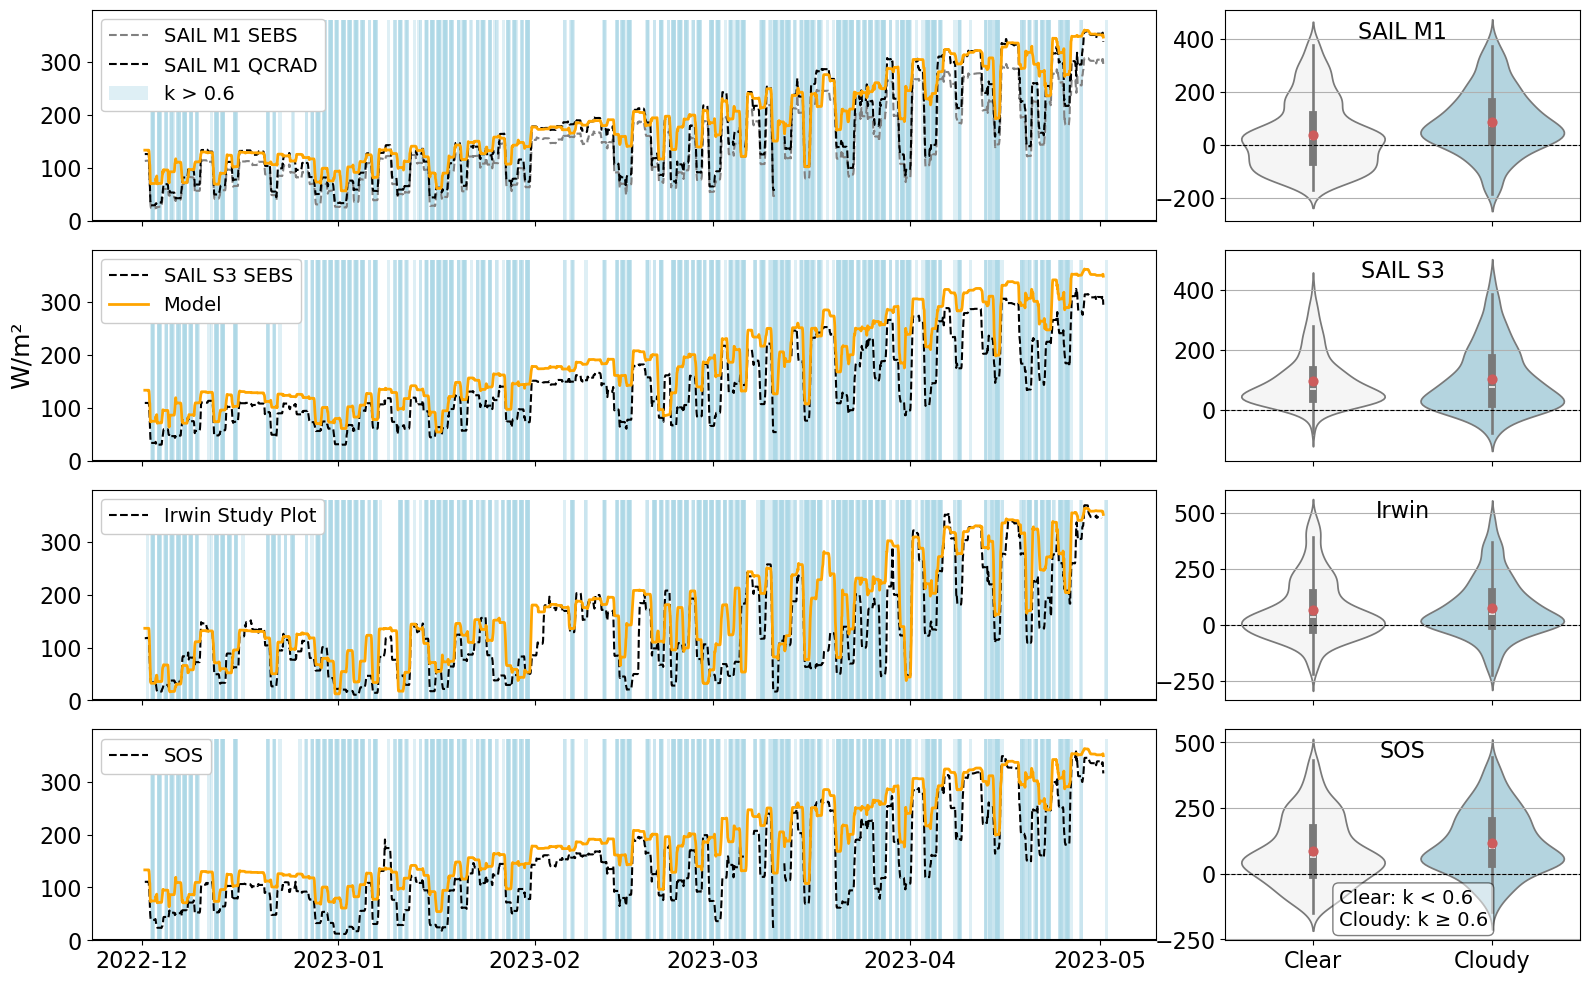

In [13]:
import seaborn as sns
import matplotlib.pyplot as plt
import pandas as pd
import numpy as np

fig, axes = plt.subplots(
    nrows=4, ncols=2, figsize=(16, 10),
    sharex='col', #sharey='row',
    gridspec_kw={'width_ratios': [3, 1]},
    constrained_layout=True
)

# Font sizes
tick_size = 16
legend_size = 14
label_size = 18
lwd = 2
# k_thresh = 0.8

# ==== Row 1: M1 ====
axes[0, 0].bar(m1_k_smoothed['time'], (m1_k_smoothed['k'] > k_thresh) * 380, #m1_model_smoothed['dsw3h'].max(),
               color='lightblue', width=0.5, alpha=0.4, label='k > 0.6')
axes[0, 0].plot(m1_obs_smoothed['time'], m1_obs_smoothed, linestyle='--', color='grey', label='SAIL M1 SEBS')
axes[0, 0].plot(m1qc_obs_smoothed['time'], m1qc_obs_smoothed, linestyle='--', color='black', label='SAIL M1 QCRAD')
axes[0, 0].plot(m1_model_smoothed['time'], m1_model_smoothed['dsw3h'], color='orange', linewidth=lwd, label='')
axes[0, 0].axhline(0, color='black')
axes[0, 0].legend(fontsize=legend_size, framealpha=1, loc='upper left')
# axes[0, 0].set_ylabel('W/m²', fontsize=label_size)
axes[0, 0].tick_params(labelsize=tick_size)

sns.violinplot(data=m1_df2, x='category', y='bias',
               palette={'Clear': 'whitesmoke', 'Cloudy': 'lightblue'},
               ax=axes[0, 1])

axes[0, 1].axhline(0, color='black', linestyle='--', linewidth=0.8)
axes[0, 1].set_ylabel("")
axes[0, 1].set_xlabel("")
axes[0, 1].grid(True, axis='y')
# axes[0, 1].legend().remove()
axes[0, 1].tick_params(labelsize=tick_size)
axes[0, 1].text(0.5, 0.95, 'SAIL M1', transform=axes[0,1].transAxes,
             fontsize=16, va='top', ha='center')

m1_means = m1_df2.groupby('category')['bias'].mean()
for i, cat in enumerate(['Clear', 'Cloudy']):
    axes[0, 1].scatter(i, m1_means[cat], color='indianred', zorder=5, s=40)




# ==== Row 0: S3 ====
# -- Time Series --
axes[1, 0].bar(s3_k_smoothed['time'], (s3_k_smoothed['k'] > k_thresh) * 380, # s3_model_smoothed['dsw3h'].max(),
               color='lightblue', width=0.5, alpha=0.4)
axes[1, 0].plot(s3_obs_smoothed['time'], s3_obs_smoothed, color='black', linestyle='--', label='SAIL S3 SEBS')
axes[1, 0].plot(s3_model_smoothed['time'], s3_model_smoothed['dsw3h'], color='orange', linewidth=lwd, label='Model')
axes[1, 0].axhline(0, color='black')
axes[1, 0].legend(fontsize=legend_size, framealpha=1, loc='upper left')
axes[1, 0].set_ylabel('W/m²', fontsize=label_size)
axes[1, 0].tick_params(labelsize=tick_size)

# -- Violin Plot --
sns.violinplot(data=s3_df2, x='category', y='bias',
               palette={'Clear': 'whitesmoke', 'Cloudy': 'lightblue'},
               ax=axes[1, 1])
axes[1, 1].axhline(0, color='black', linestyle='--', linewidth=0.8)
axes[1, 1].set_ylabel("")
axes[1, 1].set_xlabel("")
axes[1, 1].grid(True, axis='y')
# axes[1, 1].legend().remove()
axes[1, 1].tick_params(labelsize=tick_size)
axes[1, 1].text(0.5, 0.95, 'SAIL S3', transform=axes[1,1].transAxes,
             fontsize=16, va='top', ha='center')

# Add mean bias dot
s3_means = s3_df2.groupby('category')['bias'].mean()
for i, cat in enumerate(['Clear', 'Cloudy']):
    axes[1, 1].scatter(i, s3_means[cat], color='indianred', zorder=5, s=40)

# ==== Row 2: Irwin ====
axes[2, 0].bar(irwin_k_smoothed['time'], (irwin_k_smoothed['k'] > k_thresh) * 380, # irwin_model_smoothed['dsw3h'].max(),
               color='lightblue', width=0.5, alpha=0.4)
axes[2, 0].plot(irwin_obs_smoothed.index, irwin_obs_smoothed, linestyle='--', color='black', label='Irwin Study Plot')
axes[2, 0].plot(irwin_model_smoothed['time'], irwin_model_smoothed['dsw3h'], color='orange', linewidth=lwd, label='')
axes[2, 0].axhline(0, color='black')
axes[2, 0].legend(fontsize=legend_size, framealpha=1, loc='upper left')
# axes[2, 0].set_ylabel('W/m²', fontsize=label_size)
axes[2, 0].tick_params(labelsize=tick_size)

sns.violinplot(data=irwin_df2, x='category', y='bias',
               palette={'Clear': 'whitesmoke', 'Cloudy': 'lightblue'},
               ax=axes[2, 1])

axes[2, 1].axhline(0, color='black', linestyle='--', linewidth=0.8)
axes[2, 1].set_ylabel("")
axes[2, 1].set_xlabel("")
axes[2, 1].grid(True, axis='y')
# axes[2, 1].legend().remove()
axes[2, 1].tick_params(labelsize=tick_size)
axes[2, 1].text(0.5, 0.95, 'Irwin', transform=axes[2,1].transAxes,
             fontsize=16, va='top', ha='center')

irwin_means = irwin_df2.groupby('category')['bias'].mean()
for i, cat in enumerate(['Clear', 'Cloudy']):
    axes[2, 1].scatter(i, irwin_means[cat], color='indianred', zorder=5, s=40)


# # # # # ADD SOS
axes[3, 0].bar(sos_k_smoothed['time'], (sos_k_smoothed['k'] > k_thresh) * 380, # irwin_model_smoothed['dsw3h'].max(),
               color='lightblue', width=0.5, alpha=0.4)
axes[3, 0].plot(sos_obs_smoothed['time'], sos_obs_smoothed, linestyle='--', color='black', label='SOS')
axes[3, 0].plot(sos_model_smoothed['time'], sos_model_smoothed['dsw3h'], color='orange', linewidth=lwd, label='')
axes[3, 0].axhline(0, color='black')
axes[3, 0].legend(fontsize=legend_size, framealpha=1, loc='upper left')
# axes[2, 0].set_ylabel('W/m²', fontsize=label_size)
axes[3, 0].tick_params(labelsize=tick_size)

sns.violinplot(data=sos_df2, x='category', y='bias',
               palette={'Clear': 'whitesmoke', 'Cloudy': 'lightblue'},
               ax=axes[3, 1])

axes[3, 1].axhline(0, color='black', linestyle='--', linewidth=0.8)
axes[3, 1].set_ylabel("")
axes[3, 1].set_xlabel("")
axes[3, 1].grid(True, axis='y')
# axes[2, 1].legend().remove()
axes[3, 1].tick_params(labelsize=tick_size)
axes[3, 1].text(0.5, 0.95, 'SOS', transform=axes[3,1].transAxes,
             fontsize=16, va='top', ha='center')

sos_means = sos_df2.groupby('category')['bias'].mean()
for i, cat in enumerate(['Clear', 'Cloudy']):
    axes[3, 1].scatter(i, sos_means[cat], color='indianred', zorder=5, s=40)

# # # # # #
# # #

# Text and box properties
textstr = "Clear: k < 0.6\nCloudy: k ≥ 0.6"
props = dict(boxstyle='round', facecolor='white', alpha=0.5, edgecolor='black')

# Place it in bottom-left
axes[3, 1].text(
    0.32, 0.05, textstr,
    # transform=ax.transAxes,
    transform=axes[3,1].transAxes,
    fontsize=14,
    verticalalignment='bottom',
    horizontalalignment='left',
    bbox=props
)

# Final layout
plt.tight_layout()
plt.show()

svpth = "/uufs/chpc.utah.edu/common/home/u1037042/Documents/figures-2025/isnobal-oct/"
# plt.savefig(svpth + 'FigS2-WY2023-Point-SW.png', dpi=300, bbox_inches='tight')

## stats

In [16]:
k_thresh = 0.6  # or whatever your threshold is

clear_counts = {
    'M1': ((m1_k_smoothed['k'] < k_thresh).sum().item()),
    'S3': ((s3_k_smoothed['k'] < k_thresh).sum().item()),
    'SOS': ((sos_k_smoothed['k'] < k_thresh).sum().item()),
    'Irwin': ((irwin_k_smoothed['k'] < k_thresh).sum().item()),
}

cloudy_counts = {
    'M1': ((m1_k_smoothed['k'] >= k_thresh).sum().item()),
    'S3': ((s3_k_smoothed['k'] >= k_thresh).sum().item()),
    'SOS': ((sos_k_smoothed['k'] >= k_thresh).sum().item()),
    'Irwin': ((irwin_k_smoothed['k'] >= k_thresh).sum().item()),
}

# Display
for station in clear_counts:
    total = clear_counts[station] + cloudy_counts[station]
    print(f"{station}: Clear = {clear_counts[station]}, Cloudy = {cloudy_counts[station]}, Total = {total}")


M1: Clear = 2947, Cloudy = 701, Total = 3648
S3: Clear = 2885, Cloudy = 739, Total = 3624
SOS: Clear = 2906, Cloudy = 742, Total = 3648
Irwin: Clear = 2776, Cloudy = 872, Total = 3648


In [17]:
k_thresh = 0.6  # adjust if needed
sw_thresh = 1.0

clear_counts = {
    'M1': ((m1_k_smoothed['k'] < k_thresh) & (m1_model_smoothed['dsw3h'] > sw_thresh)).sum().item(),
    'S3': ((s3_k_smoothed['k'] < k_thresh) & (s3_model_smoothed['dsw3h'] > sw_thresh)).sum().item(),
    'SOS': ((sos_k_smoothed['k'] < k_thresh) & (sos_model_smoothed['dsw3h'] > sw_thresh)).sum().item(),
    'Irwin': ((irwin_k_smoothed['k'] < k_thresh) & (irwin_model_smoothed['dsw3h'] > sw_thresh)).sum().item(),
}

cloudy_counts = {
    'M1': ((m1_k_smoothed['k'] >= k_thresh) & (m1_model_smoothed['dsw3h'] > sw_thresh)).sum().item(),
    'S3': ((s3_k_smoothed['k'] >= k_thresh) & (s3_model_smoothed['dsw3h'] > sw_thresh)).sum().item(),
    'SOS': ((sos_k_smoothed['k'] >= k_thresh) & (sos_model_smoothed['dsw3h'] > sw_thresh)).sum().item(),
    'Irwin': ((irwin_k_smoothed['k'] >= k_thresh) & (irwin_model_smoothed['dsw3h'] > sw_thresh)).sum().item(),
}

# Display
for station in clear_counts:
    total = clear_counts[station] + cloudy_counts[station]
    print(f"{station}: Clear = {clear_counts[station]}, Cloudy = {cloudy_counts[station]}, Total = {total}")


M1: Clear = 2925, Cloudy = 700, Total = 3625
S3: Clear = 2863, Cloudy = 738, Total = 3601
SOS: Clear = 2884, Cloudy = 741, Total = 3625
Irwin: Clear = 2755, Cloudy = 870, Total = 3625


In [19]:
k_thresh = 0.6
sw_thresh = 1.0

stations = {
    'M1': (m1_k_smoothed['k'], m1_model_smoothed['dsw3h']),
    'S3': (s3_k_smoothed['k'], s3_model_smoothed['dsw3h']),
    'SOS': (sos_k_smoothed['k'], sos_model_smoothed['dsw3h']),
    'Irwin': (irwin_k_smoothed['k'], irwin_model_smoothed['dsw3h']),
}

for name, (k_data, sw_data) in stations.items():
    # Mask where SW > threshold
    valid = sw_data > sw_thresh

    # Apply conditions
    clear = ((k_data < k_thresh) & valid).sum().item()
    cloudy = ((k_data >= k_thresh) & valid).sum().item()
    total = clear + cloudy

    # Percentages
    clear_pct = 100 * clear / total if total > 0 else 0
    cloudy_pct = 100 * cloudy / total if total > 0 else 0

    print(f"{name}:")
    print(f"  Total valid hours: {total}")
    print(f"  Clear hours: {clear} ({clear_pct:.1f}%)")
    print(f"  Cloudy hours: {cloudy} ({cloudy_pct:.1f}%)")
    print()


M1:
  Total valid hours: 3625
  Clear hours: 2925 (80.7%)
  Cloudy hours: 700 (19.3%)

S3:
  Total valid hours: 3601
  Clear hours: 2863 (79.5%)
  Cloudy hours: 738 (20.5%)

SOS:
  Total valid hours: 3625
  Clear hours: 2884 (79.6%)
  Cloudy hours: 741 (20.4%)

Irwin:
  Total valid hours: 3625
  Clear hours: 2755 (76.0%)
  Cloudy hours: 870 (24.0%)



# direct & diffuse

In [14]:
# Create bias df

# S3 and M1 from xarray
# m1_df = compute_bias_and_category2(m1_obs_hourly, m1_dsw3, m1_k, 'SAIL M1 QCRAD', start, end, k_thresh)
m1_dir = compute_bias_and_category2(dirh_obs, dirh_model, m1_k, 'SAIL M1 DIR', start, end, k_thresh)
m1_dif = compute_bias_and_category2(dif_obs, dif_model, m1_k, 'SAIL M1 DIF', start, end, k_thresh)


# m1_df2 = limit_2_98(m1_df)
m1_dir2 = limit_2_98(m1_dir)
m1_dif2 = limit_2_98(m1_dif)

In [16]:
m1_dir2['bias'].mean()
# m1_dir2['bias'].std()

np.float32(57.941677)

In [17]:
m1_dif2['bias'].mean()
# m1_dif2['bias'].std()

np.float32(16.790983)

In [18]:
print("SW Bias by Component (Modeled - Station)")
print("\nSAIL M1 QCRAD:")
print(m1_df2.groupby('category')['bias'].agg(['min', 'mean', 'max']))
print("\nM1 Direct:")
print(m1_dir2.groupby('category')['bias'].agg(['min', 'mean', 'max']))
print("\nM1 Diffuse:")
print(m1_dif2.groupby('category')['bias'].agg(['min', 'mean', 'max']))

SW Bias by Component (Modeled - Station)

SAIL M1 QCRAD:
                 min       mean         max
category                                   
Clear    -171.403320  37.126450  398.022949
Cloudy   -184.887634  86.486938  408.631500

M1 Direct:
                 min       mean         max
category                                   
Clear    -258.831421  91.791824  545.212952
Cloudy   -270.634155  11.878701  335.968872

M1 Diffuse:
                 min       mean         max
category                                   
Clear    -297.592102 -43.187157  293.660858
Cloudy   -219.699188  94.124123  326.872284


/scratch/local/u1037042/6836649/ipykernel_3237711/4117156110.py:25: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.violinplot(data=m1_df2, x='category', y='bias',
/scratch/local/u1037042/6836649/ipykernel_3237711/4117156110.py:54: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.violinplot(data=m1_dir2, x='category', y='bias',
/scratch/local/u1037042/6836649/ipykernel_3237711/4117156110.py:79: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.violinplot(data=m1_dif2, x='category', y='bias',


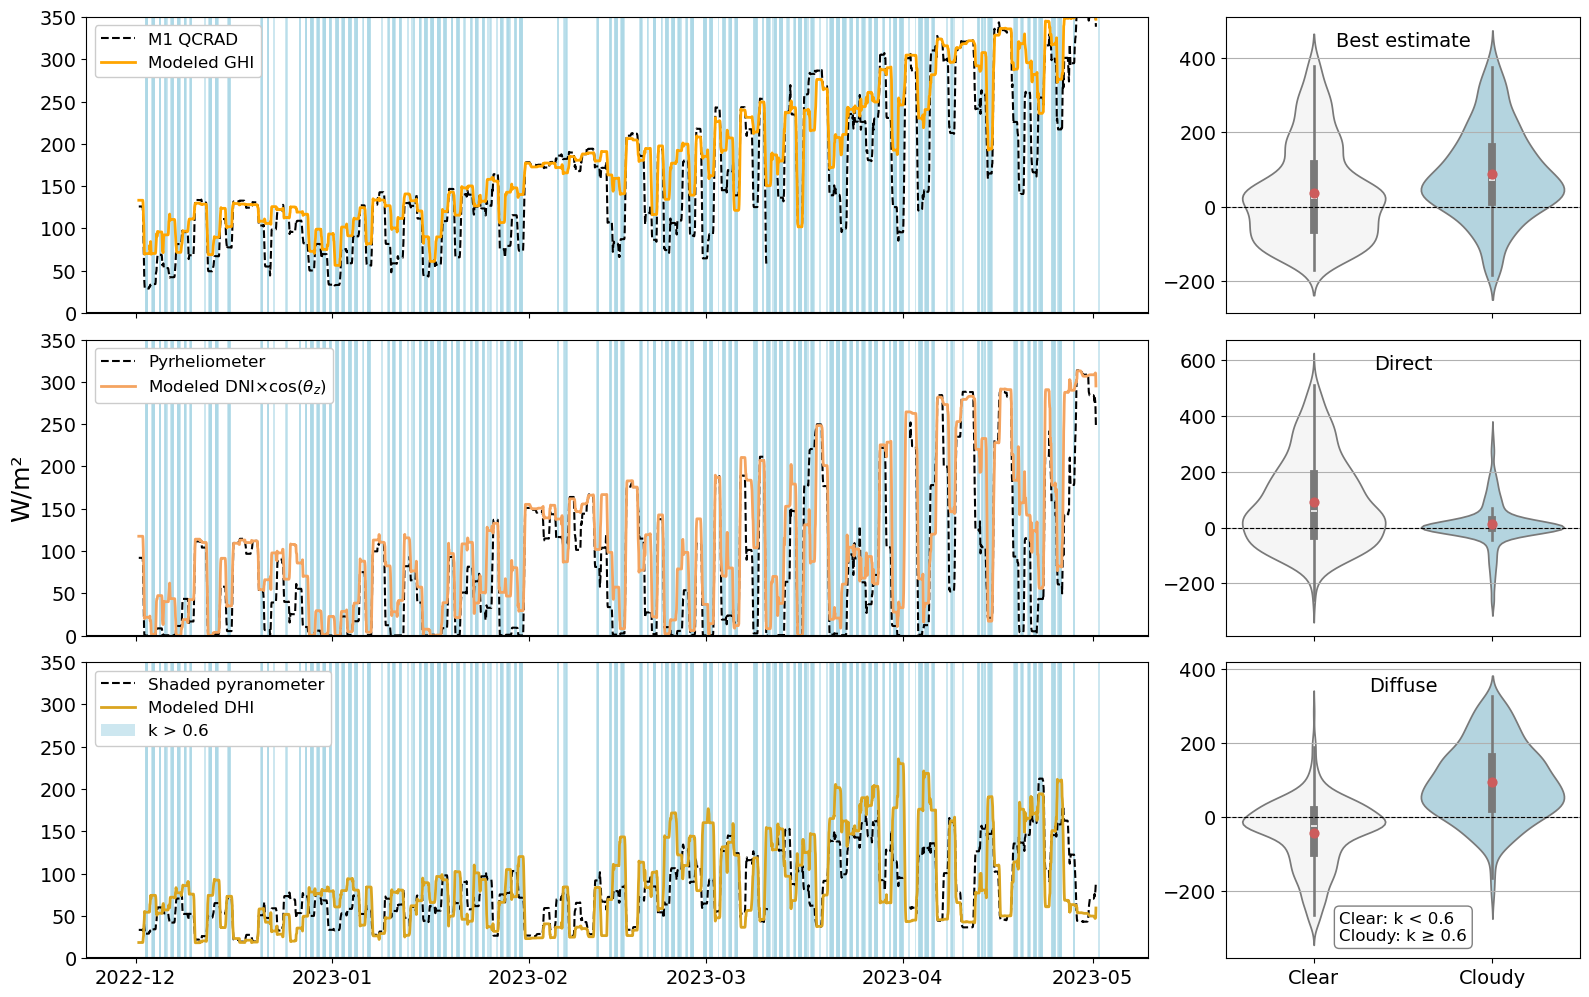

In [19]:
# PLOT FIGURE 2

fig, axes = plt.subplots(
    nrows=3, ncols=2, figsize=(16, 10),
    sharex='col',
    gridspec_kw={'width_ratios': [3, 1]}
)

tick_size = 14
legend_size = 12
label_size = 18
lwd = 2
k_thresh = 0.6


# ===== Row 1: Best =====
axes[0, 0].bar(m1_k_smoothed['time'], (m1_k_smoothed['k'] > k_thresh) * 380, #m1_model_smoothed['dsw3h'].max(), #350, #m1_model_smoothed['dsw3h'].max(),
               color='lightblue', width=0.3, alpha=0.6)
axes[0, 0].plot(m1qc_obs_smoothed['time'], m1qc_obs_smoothed, linestyle='--', color='black', label='M1 QCRAD')
axes[0, 0].plot(m1_model_smoothed['time'], m1_model_smoothed['dsw3h'], color='orange', linewidth=lwd, label='Modeled GHI')
axes[0, 0].axhline(0, color='black')
axes[0, 0].legend(fontsize=legend_size, framealpha=1, loc='upper left')
axes[0, 0].tick_params(labelsize=tick_size)

sns.violinplot(data=m1_df2, x='category', y='bias',
               palette={'Clear': 'whitesmoke', 'Cloudy': 'lightblue'},
               ax=axes[0, 1])
axes[0, 1].axhline(0, color='black', linestyle='--', linewidth=0.8)
axes[0, 1].text(0.5, 0.95, 'Best estimate', transform=axes[0, 1].transAxes,
                fontsize=14, va='top', ha='center')
axes[0, 1].tick_params(labelsize=tick_size)
axes[0, 1].grid(True, axis='y')
axes[0, 1].set_ylabel("")
axes[0, 1].set_xlabel("")

best_means = m1_df2.groupby('category')['bias'].mean()
for i, cat in enumerate(['Clear', 'Cloudy']):
    axes[0, 1].scatter(i, best_means[cat], color='indianred', zorder=5, s=40)



# ===== Row 2: Direct =====
axes[1, 0].bar(m1_k_smoothed['time'], (m1_k_smoothed['k'] > k_thresh) * 380, #m1_model_smoothed['dsw3h'].max(), #350, #dir_model_smoothed.max(),
               color='lightblue', width=0.3, alpha=0.6)

axes[1, 0].plot(dirh_obs_smoothed['time'], dirh_obs_smoothed, linestyle='--', color='black', label='Pyrheliometer')
axes[1, 0].plot(dirh_model_smoothed['time'], dirh_model_smoothed['dsw3h'], color='sandybrown', linewidth=lwd, label=r'Modeled DNI$\times \cos(\theta_z)$')

axes[1, 0].axhline(0, color='black')
axes[1, 0].legend(fontsize=legend_size, framealpha=1, loc='upper left')
axes[1, 0].set_ylabel('W/m²', fontsize=label_size)
axes[1, 0].tick_params(labelsize=tick_size)

sns.violinplot(data=m1_dir2, x='category', y='bias',
               palette={'Clear': 'whitesmoke', 'Cloudy': 'lightblue'},
               ax=axes[1, 1])
axes[1, 1].axhline(0, color='black', linestyle='--', linewidth=0.8)
axes[1, 1].text(0.5, 0.95, 'Direct', transform=axes[1, 1].transAxes,
                fontsize=14, va='top', ha='center')
axes[1, 1].tick_params(labelsize=tick_size)
axes[1, 1].grid(True, axis='y')
axes[1, 1].set_ylabel("")
axes[1, 1].set_xlabel("")

dir_means = m1_dir2.groupby('category')['bias'].mean()
for i, cat in enumerate(['Clear', 'Cloudy']):
    axes[1, 1].scatter(i, dir_means[cat], color='indianred', zorder=5, s=40)


# ===== Row 3: Diffuse =====
axes[2, 0].bar(m1_k_smoothed['time'], (m1_k_smoothed['k'] > k_thresh) * 380, #m1_model_smoothed['dsw3h'].max(), #350, #dif_model_smoothed.max(),
               color='lightblue', width=0.3, alpha=0.6, label='k > 0.6')
axes[2, 0].plot(dif_obs_smoothed['time'], dif_obs_smoothed, color='black', linestyle='--', label='Shaded pyranometer')
axes[2, 0].plot(dif_model_smoothed['time'], dif_model_smoothed['dsw3h'], color='goldenrod', linewidth=lwd, label='Modeled DHI')
axes[2, 0].axhline(0, color='black')
axes[2, 0].legend(fontsize=legend_size, framealpha=1, loc='upper left')
axes[2, 0].tick_params(labelsize=tick_size)

sns.violinplot(data=m1_dif2, x='category', y='bias',
               palette={'Clear': 'whitesmoke', 'Cloudy': 'lightblue'},
               ax=axes[2, 1])
axes[2, 1].axhline(0, color='black', linestyle='--', linewidth=0.8)
axes[2, 1].text(0.5, 0.95, 'Diffuse', transform=axes[2, 1].transAxes,
                fontsize=14, va='top', ha='center')
axes[2, 1].tick_params(labelsize=tick_size)
axes[2, 1].grid(True, axis='y')
axes[2, 1].set_ylabel("")
axes[2, 1].set_xlabel("")

dif_means = m1_dif2.groupby('category')['bias'].mean()
for i, cat in enumerate(['Clear', 'Cloudy']):
    axes[2, 1].scatter(i, dif_means[cat], color='indianred', zorder=5, s=40)

# Text and box properties
textstr = "Clear: k < 0.6\nCloudy: k ≥ 0.6"
props = dict(boxstyle='round', facecolor='white', alpha=0.5, edgecolor='black')

# Place it in bottom-left
axes[2, 1].text(
    0.32, 0.05, textstr,
    # transform=ax.transAxes,
    transform=axes[2,1].transAxes,
    fontsize=12,
    verticalalignment='bottom',
    horizontalalignment='left',
    bbox=props
)

# Set to all left-side axes
for ax in [axes[0, 0], axes[1, 0], axes[2, 0]]:
    # ax.set_ylim(shared_ymin, shared_ymax)
    ax.set_ylim(0, 350)

# Final layout
plt.tight_layout()

plt.show()
# svpth = "/uufs/chpc.utah.edu/common/home/u1037042/Documents/figures-2025/isnobal-figs-july-2025/"
# plt.savefig(svpth + 'fig02-wy22-m1-dir-dif-bias.png', dpi=300, bbox_inches='tight')

# K

In [20]:
m1_obs_k = sub_difh_hourly['__xarray_dataarray_variable__'] / subset_best_hourly['BestEstimate_down_short_hemisp']
m1_obs_k = m1_obs_k.rename('k').clip(min=0, max=1)

In [21]:
import xarray as xr
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from scipy.stats import pearsonr
import statsmodels.api as sm

# Step 1: Align datasets by overlapping time
start_time = max(m1_k.time.min().values, m1_obs_k.time.min().values)
end_time = min(m1_k.time.max().values, m1_obs_k.time.max().values)

m1_k_aligned = m1_k.sel(time=slice(start_time, end_time))
m1_obs_k_aligned = m1_obs_k.sel(time=slice(start_time, end_time))

# Step 2: Extract 'k' from modeled dataset
k_modeled = m1_k_aligned['k'].to_series()

# Step 3: Extract or define 'k' for observed dataset
# If 'k' is not present in m1_obs_k, define it manually like this:
# m1_obs_k['k'] = xr.DataArray(...)

# if 'k' not in m1_obs_k_aligned:
#     raise ValueError("Observed dataset (m1_obs_k) does not contain variable 'k'.")

k_observed = m1_obs_k_aligned.to_series()

# Step 4: Resample observed k to match modeled frequency (assumed hourly)
k_observed_resampled = k_observed.resample('h').mean()

# Step 5: Align by common time index
common_index = k_modeled.index.intersection(k_observed_resampled.index)
k_modeled_aligned = k_modeled.loc[common_index]
k_observed_aligned = k_observed_resampled.loc[common_index]

# Step 6: Remove missing values
df = pd.DataFrame({
    'modeled': k_modeled_aligned,
    'observed': k_observed_aligned
}).dropna()

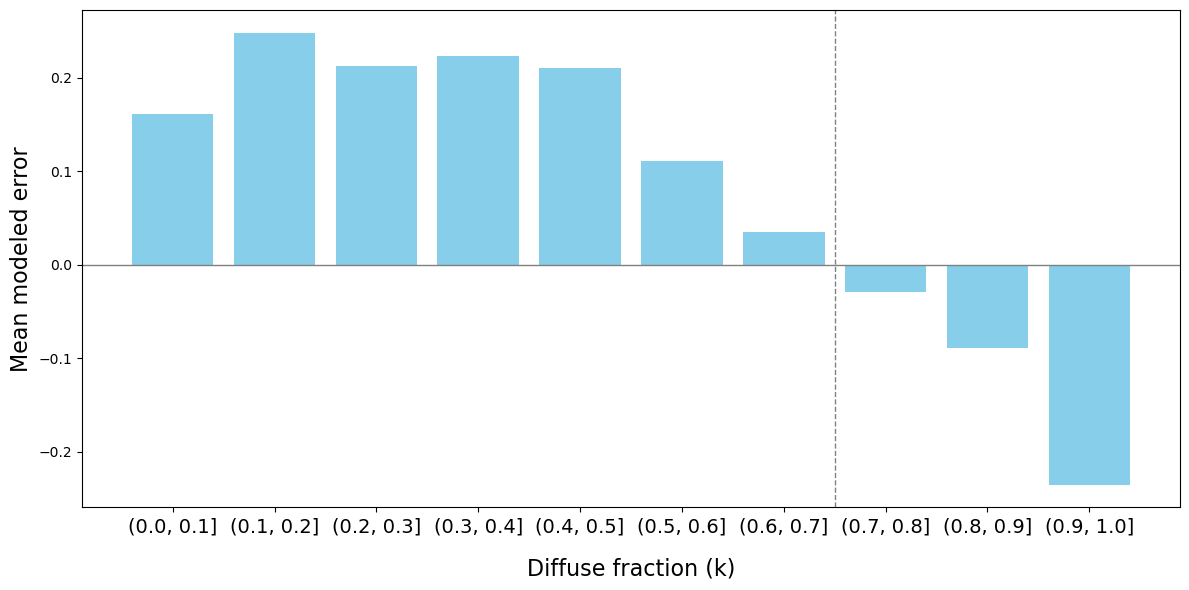

In [22]:
# Step 1: Compute absolute error
# df['abs_error'] = np.abs(df['modeled'] - df['observed'])
df['abs_error'] = (df['modeled'] - df['observed'])

# Step 2: Bin the observed k into 0.1 increments
df['k_bin'] = pd.cut(df['observed'], bins=np.arange(0, df['observed'].max() + 0.1, 0.1))

# Step 3: Group by bin and compute mean error
bin_error = df.groupby('k_bin', observed=True)['abs_error'].mean().reset_index()

# Step 4: Plot
plt.figure(figsize=(12,6))
plt.axhline(y=0, color='grey', linewidth=1)     # Horizontal line at y=0
plt.axvline(x=6.5, color='grey', linewidth=1, linestyle='--')    # Vertical line at x=6.5
plt.bar(bin_error['k_bin'].astype(str), bin_error['abs_error'], color='skyblue')
plt.xticks(rotation=0, fontsize=14)
plt.xlabel('Diffuse fraction (k)', fontsize=16, labelpad=15)
plt.ylabel('Mean modeled error', fontsize=16)
# plt.ylabel('Mean Absolute Error', fontsize=16)
plt.tight_layout()
plt.show()

# svpth = "/uufs/chpc.utah.edu/common/home/u1037042/Documents/figures-2025/isnobal-figs-july-2025/"
# plt.savefig(svpth + 'k-bias-bar.png', dpi=300, bbox_inches='tight')

/scratch/local/u1037042/6836649/ipykernel_3237711/3371954706.py:25: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  box = plt.boxplot(data, labels=labels, showfliers=False)


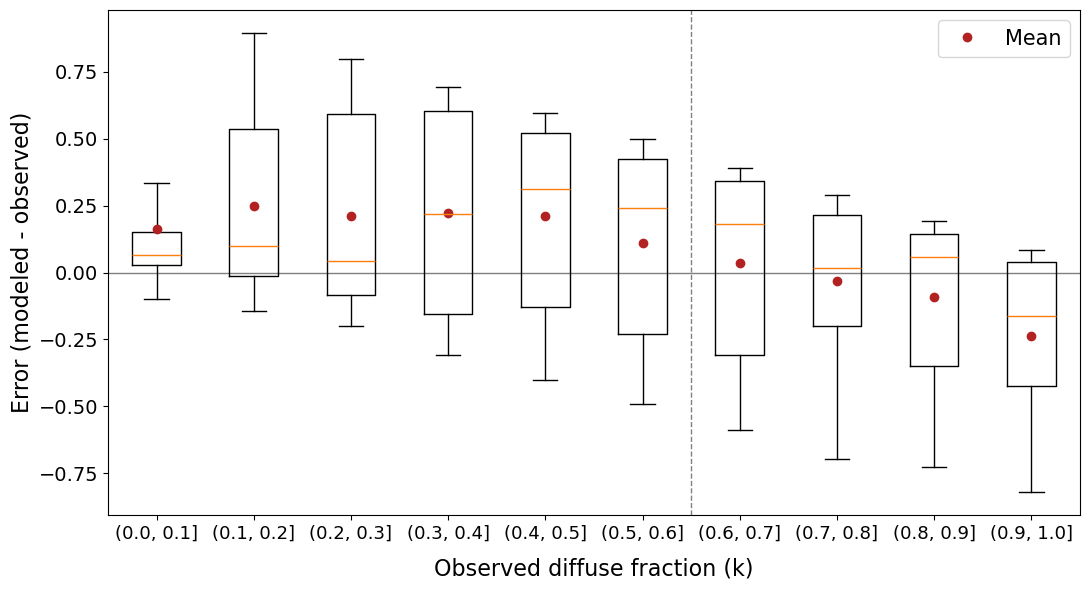

In [23]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

# Step 1: Calculate signed error
df['error'] = df['modeled'] - df['observed']

# Step 2: Bin the observed values into 0.1 increments
df['k_bin'] = pd.cut(df['observed'], bins=np.arange(0, df['observed'].max() + 0.1, 0.1))

# Step 3: Group by bins
grouped = df.groupby('k_bin', observed=True)['error']

# Step 4: Prepare data for boxplot and means
data = [group.dropna().values for _, group in grouped]
labels = [str(interval) for interval in grouped.groups.keys()]
means = [group.mean() for _, group in grouped]

# Step 5: Plot
plt.figure(figsize=(11,6))
plt.axhline(y=0, color='grey', linewidth=1)     # Horizontal reference line at y=0
plt.axvline(x=6.5, color='grey', linewidth=1, linestyle='--')  # Optional: vertical ref line

# Boxplot
box = plt.boxplot(data, labels=labels, showfliers=False)

# Overlay mean points
plt.plot(range(1, len(means)+1), means, color='firebrick', marker='o', linestyle='None', label='Mean')

# Final formatting
# plt.xticks(rotation=90, fontsize=12)
plt.xlabel('Observed diffuse fraction (k)', fontsize=16, labelpad=10)
plt.ylabel('Error (modeled - observed)', fontsize=16)
plt.xticks(rotation=0, fontsize=13)
plt.yticks(fontsize=14)
plt.legend(fontsize=15)
plt.tight_layout()
plt.show()

svpth = "/uufs/chpc.utah.edu/common/home/u1037042/Documents/figures-2025/isnobal-sep/"
# plt.savefig(svpth + 'k-bias-dist.png', dpi=300, bbox_inches='tight')

In [24]:
bin_error

,k_bin,abs_error
0,"(0.0, 0.1]",0.161034
1,"(0.1, 0.2]",0.248115
2,"(0.2, 0.3]",0.212140
3,"(0.3, 0.4]",0.222735
4,"(0.4, 0.5]",0.209738
5,"(0.5, 0.6]",0.110500
6,"(0.6, 0.7]",0.034750
7,"(0.7, 0.8]",-0.029634
8,"(0.8, 0.9]",-0.089639
9,"(0.9, 1.0]",-0.235579
